<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/Intermediate_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Chinese automobile company aspires to enter the US market by setting up their manufacturing unit
there and producing cars locally to give competition to their US and European counterparts. They have
contracted an automobile consulting company to understand the factors on which the pricing of cars
depends. Specifically, they want to understand the factors affecting the pricing of cars in the American
market, since those may be very different from the Chinese market. Essentially, the company wants to
know:
Which variables are significant in predicting the price of a car?
How well those variables describe the price of a car?
Based on various market surveys, the consulting firm has gathered a large dataset of different types of
cars across the American market.  


**Business Goal:** You are required to model the price of cars with the available independent variables. It
will be used by the management to understand how exactly the prices vary with the independent
variables. They can accordingly manipulate the design of the cars, the business strategy, etc., to meet
certain price levels. Further, the model will be a good way for the management to understand the pricing
dynamics of a new market.

**Key components to be fulfilled:**
**1. Loading and Preprocessing (5 marks)**: Load the dataset and perform necessary preprocessing
steps.
**2. Model Implementation (10 marks):** Implement the following five regression algorithms:
● Linear Regression
● Decision Tree Regressor
● Random Forest Regressor
● Gradient Boosting Regressor
● Support Vector Regressor
**3. Model Evaluation (5 marks):** Compare the performance of all the models based on R-squared,
Mean Squared Error (MSE), and Mean Absolute Error (MAE). Identify the best performing model
and justify why it is the best.
**4. Feature Importance Analysis (2 marks):** Identify the significant variables affecting car prices
(feature selection)
**5. Hyperparameter Tuning (2 marks): **Perform hyperparameter tuning and check whether the
performance of the model has increased.
**6. Timely Submission (1 mark) Submission Guidelines:** - Provide your code in a Jupyter Notebook
format and submit the GitHub link here. - Ensure your explanations and answers are clear and
concise.

In [1]:
#1. Loading and Preprocessing (5 marks): Load the dataset and perform necessary preprocessing steps.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Load Dataset
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.CarName

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
...,...
200,volvo 145e (sw)
201,volvo 144ea
202,volvo 244dl
203,volvo 246


In [5]:
# Extract Manufacturer Name from CarName
df['CompanyName'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

In [8]:
df['CompanyName'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [9]:
# Correct spelling errors in company names
df['CompanyName'] = df['CompanyName'].replace({
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota'
})

In [10]:
# Drop non-predictive / redundant columns
df_clean = df.drop(columns=['car_ID', 'CarName'])

In [11]:
# Separate Independent Variables (X) and Target Variable (y)
X = df_clean.drop(columns=['price'])
y = df_clean['price']

In [12]:
# One-Hot Encoding for Categorical Features
X_encoded = pd.get_dummies(X, drop_first=True)

In [13]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [14]:
# Feature Scaling for distance/gradient-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (164, 64)
Testing set shape: (41, 64)


In [15]:
#2. Model Implementation & 3. Model Evaluation (10 + 5 Marks)
# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

results = []

# Fit and Evaluate Models
for name, model in models.items():
    if name in ["Linear Regression", "Support Vector Regressor"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

# Format Baseline Results Table
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("--- Baseline Model Performance Comparison ---")
print(results_df.to_string(index=False))


--- Baseline Model Performance Comparison ---
                   Model  R2 Score          MSE        RMSE         MAE
           Random Forest  0.958417 3.282767e+06 1811.840721 1288.825012
       Gradient Boosting  0.924181 5.985429e+06 2446.513705 1710.336389
       Linear Regression  0.909701 7.128547e+06 2669.933854 1763.565986
           Decision Tree  0.906907 7.349134e+06 2710.928531 1782.589439
Support Vector Regressor -0.100646 8.688943e+07 9321.450187 5701.535891


In [16]:
#Random forest prformed well

--- Top 10 Significant Features Affecting Car Price ---
enginesize         0.544159
curbweight         0.298449
highwaympg         0.044743
horsepower         0.033483
carwidth           0.013090
carlength          0.007767
CompanyName_bmw    0.007114
wheelbase          0.006991
citympg            0.006420
peakrpm            0.006174
dtype: float64


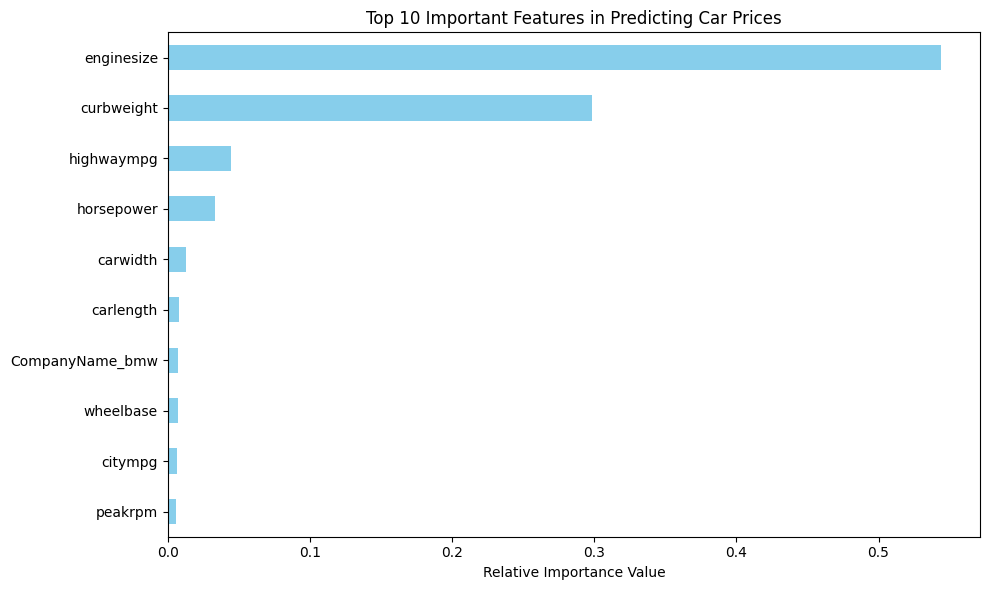

In [17]:
# Top 10 Feature Importances from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

print("--- Top 10 Significant Features Affecting Car Price ---")
print(importances.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Important Features in Predicting Car Prices')
plt.xlabel('Relative Importance Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# Hyperparameter Tuning for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print("--- Tuned Random Forest ---")
print("Best Hyperparameters:", grid_rf.best_params_)
print("Tuned R2 Score:", r2_score(y_test, y_pred_rf_tuned))
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_rf_tuned))

#Hyperparameter Tuning for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

print("\n--- Tuned Gradient Boosting ---")
print("Best Hyperparameters:", grid_gb.best_params_)
print("Tuned R2 Score:", r2_score(y_test, y_pred_gb_tuned))
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_gb_tuned))

--- Tuned Random Forest ---
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned R2 Score: 0.9595497871948259
Tuned MAE: 1248.1212418699188

--- Tuned Gradient Boosting ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuned R2 Score: 0.9400040515633108
Tuned MAE: 1595.6157512353413
